# Generate Plots of Absolute Geostrophic Velocity in transects of the Beaufort Gyre

### Configure the notebook and load necessary packages

In [8]:
#Jupyter Notebook config
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
#Load necessary python packages
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cmocean import cm
import numpy as np

#Import custom package for working with Beaufort Gyre data
from datatools import io
import datatools.ctd.operations as dsops
import datatools.plots.maps as mapper
import datatools.plots.section as plotter
import ocean_tools as fod

### Extract the CTD Transects from the full dataset
* Read in the data
* Extract each transect
* Plot the transects on a map

In [10]:
#Read raw CTD data
ds = io.readers.readLSSL("/Users/ben/Desktop/3D-TEA-BAG/data/BG_LSSL_CTD_2003-2025.nc")

#Slice the data to extract each transect
#Eastern N-S transect (IVO 140˚W)
e_ns_transect = dsops.var_slice(ds, 'lon', -140.5, -139.5)
#ADD OTHER THREE TRANSECTS

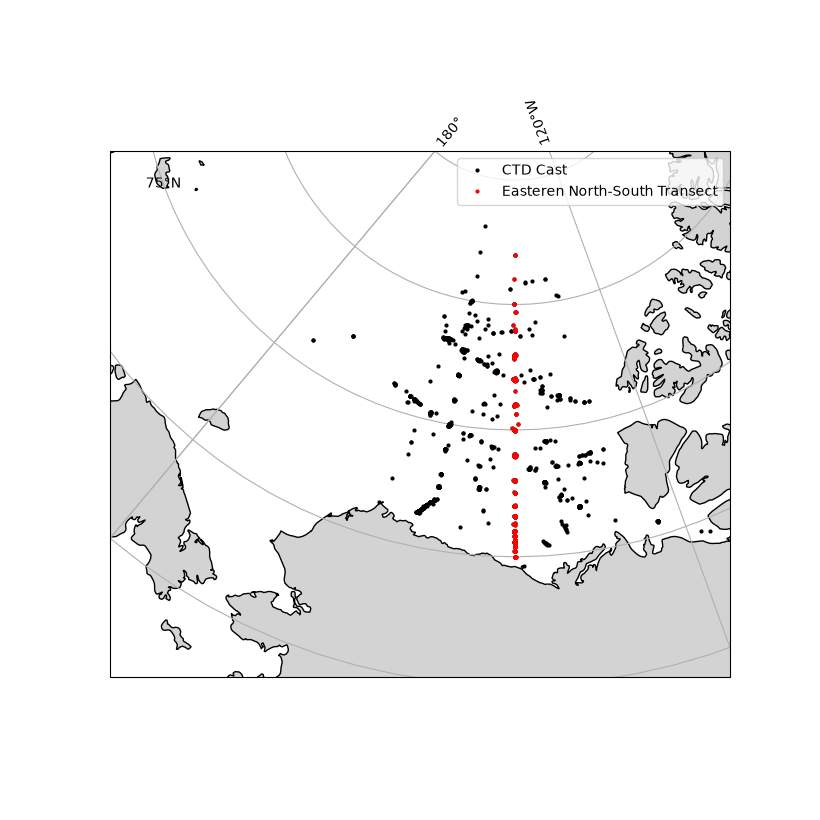

In [11]:
#Plot the transects

#Setup the basemap
transect_location_figure = plt.figure(figsize=(8,8))
projection=ccrs.NorthPolarStereo(central_longitude=-140)
extent = [-180, -120, 65, 85]

ax = mapper.setup_map(figure=transect_location_figure,
                 projection=projection,
                 extent=extent)

#Plot all casts
ax = mapper.plot_station_locations(ax = ax, ds = ds, label = 'CTD Cast')

#Plat the transects
ax = mapper.plot_station_locations(ax = ax, ds = e_ns_transect, color='r', label = 'Easteren North-South Transect')

#Finish the plot off
plt.title("Beaufort Gyre Exploration Project Shipboard CTD Cast Locations") #WHY DOESNT THIS WORK?
plt.legend()

plt.show()

### Preprocess the CTD Transects
* Split each transect dataset into an array of data arrays (one for each cruise year)
* Run the injest/cleaning function on each array of transects to remove nan data, calculate various parameters, ensure all variable naming is consistent, and add variable metadata to easier plotting later on
* Includes calculature thermal wind shear ($\frac{\partial \vec{V_g}}{\partial z} = \frac{g}{\rho f_c}(\nabla \times \rho)$)

In [14]:
#Split data into a dataset per cruise 
e_ns_cruise_transects = dsops.split_by_coordinate(e_ns_transect, 'cruise')
#Clean each dataset
for key in e_ns_cruise_transects:
    #Clean and injest the transect data (add many new and useful variables)
    e_ns_cruise_transects[key] = dsops.injest_CTD_transect(e_ns_cruise_transects[key], datum=(70,-140))

### Calculate Absolute Geostrophic Velocity
$\vec{V_g} = \int_{z_0}^{z} \frac{\partial \vec{V_g}}{\partial z} \,dz + \vec{V}_{g, z_0}$
1. Calculate based on a level of no motion of 1000m
2. Calculate based on satelite derived surface geostrophic current


#### Level of no motion at 1000m

In [ ]:
import xarray as xr
transect = e_ns_cruise_transects
twind_shear = e_ns_cruise_transects[2003]['twind']
level_no_motion = 1000

#Integrate from surface to level of no motion
shallow_twind_shear = twind_shear.where(twind_shear['depth']<= level_no_motion, drop=True).isel(depth=slice(None, None, -1)) #Flip array to integrate up from the level of no motion to the surface


shallow_agv = shallow_twind_shear.cumulative_integrate(coord='depth').isel(depth=slice(None, None, -1)) #Flip array again so depth is positive down, increasing with depth

shallow_agv

#TO FIX, HOW TO HANDEL IF DATA IS SHALLOWER THAN LEVEL OF NO MOTION (NO MOTION IS AT THE BOTTOM?)

#Integrate from level of no motion to bottom
# deep_twind_shear = twind_shear.where(twind_shear['depth'] > level_no_motion, drop = True)
# deep_agv = deep_twind_shear.integrate(coord='depth')

# abs_geo_vel = xr.concat((shallow_agv, deep_agv), dim='station')
# twind_shear

<xarray.DataArray 'twind' (station: 14, depth: 1012)> Size: 113kB
array([[            nan,             nan,             nan, ...,
                    nan,             nan,  0.00000000e+00],
       [            nan,             nan,             nan, ...,
                    nan,             nan,  0.00000000e+00],
       [            nan,             nan,             nan, ...,
                    nan,             nan,  0.00000000e+00],
       ...,
       [-1.79586023e-02, -1.78146693e-02, -1.72612854e-02, ...,
        -1.23976622e-06, -6.00476857e-07,  0.00000000e+00],
       [-2.06093218e-02, -2.01094691e-02, -1.96049725e-02, ...,
         6.38514688e-08,  2.77685469e-08,  0.00000000e+00],
       [-2.14582720e-02, -2.01809998e-02, -1.96926565e-02, ...,
        -2.27816042e-07, -1.28899310e-07,  0.00000000e+00]],
      shape=(14, 1012))
Coordinates:
  * station  (station) int64 112B 23 22 21 18 17 16 14 102 89 87 85 70 71 72
  * depth    (depth) float64 8kB 0.9896 1.979 2.969 3.959 ... 997.1 998.1 999.1
    prs      (depth) float64 8kB 1.0 2.0 3.0 ... 1.01e+03 1.011e+03 1.012e+03
    cruise   int64 8B 2003